In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import random
import math
from matplotlib.ticker import MultipleLocator


# Job Shop Scheduling

Анастасија Голић, Вељко Радојичић

*Job Shop Scheduling* је проблем оптимизације који се бави распоређивањем низа задатака (послова) на ограничене ресурсе (машине), с циљем минимизације укупног времена трајања производног процеса, уз поштовање одређених ограничења.
### Опис проблема




Претпоставимо да је потребно да машине $M = \{M_1, M_2, \dots, M_m\}$ обраде послове $J = \{J_1, J_2, \dots, J_n\}$, где се сваки посао $J_i$ састоји од $n_i$ операција $O_{i1}, O_{i2}, \dots, O_{in_i}$ и свака операција $O_{ij}$ захтева одређено време обраде $p_{ij}$, а за сваку операцију $O_{ij}$ постоји скуп машина $\mu_{ij} \subseteq \{M_1, M_2, \dots, M_m\}$, на којима операција може да се извршава. У зависности од броја операција послова и броја машина на којима операције могу да се извршавају, постоје различите модификације проблема.

Основни проблем распоређивања послова подразумева је скуп операција на којима се нека операција може извршити једночлан, односно да свака операција може да се извршава на само једном машини. Осим тога, сматраћемо да се сви послови састоје од једнаког броја операција и да постоји зависност у редоследу обраде операција. Дакле уколико се послоови састоје од $m$ операција, оне се извршавају на $m$ машина (за сваку операцију по једна машина) и једна операција истог посла не може почети док претходна није завршена. Такође у једном тренутку једна машина може обрађивати само једну операцију. Циљ оптимизације је распоређивање послова по машинама тако да укупно време извршавања свих послова буде минимално.



# ПРИМЕР

<table>
  <tr>
    <td>
      <table border="1">
        <tr>
          <th>Послови</th>
          <th>Секвенца</th>
          <th>операција</th>
          <th></th>
        </tr>
        <tr>
          <td>$J_1$</td>
          <td>2</td>
          <td>3</td>
          <td>1</td>
        </tr>
        <tr>
          <td>$J_2$</td>
          <td>3</td>
          <td>1</td>
          <td>2</td>
        </tr>
        <tr>
          <td>$J_3$</td>
          <td>1</td>
          <td>2</td>
          <td>3</td>
        </tr>
      </table>
    </td>
    <td>
      <table border="">
        <tr>
          <th>Послови</th>
          <th>Време      </th>
          <th>обраде</th>
          <th>      </th>
        </tr>
        <tr>
          <td>$J_1$</td>
          <td>3</td>
          <td>4</td>
          <td>1</td>
        </tr>
        <tr>
          <td>$J_2$</td>
          <td>6</td>
          <td>2</td>
          <td>4</td>
        </tr>
        <tr>
          <td>$J_3$</td>
          <td>2</td>
          <td>5</td>
          <td>5</td>
        </tr>
      </table>
    </td>
  </tr>
</table>






Табеле илуструју пример проблема са три посла која се извршавају на три машине. Прва табела односи се на секвенцу извршавања операција(на којоим машинама се редом извршавају операције), док се друга табела односи на врме извршавања одређених операција. Може се закључити да је у оквиру посла $J_1$ прву операцију потребно обрадити на машини $M_2$, и да је време обраде операције $O_{11}$ једнако 3 јединице времена. У складу усвојеним ограничењима операција $O_{11}$ ће почети за извршавањем тек када  машина $M_2$ буде ослобођена. Следећа операција посла $J_1$ je операција $O_{12}$ и обрађује на машини $M_3$ уколико је завршено извршавање операције $O_{11}$, односно претходне операције посла, и уколико је машина $M_3$ завршила обраду свих претхоно распоређених операција.Уколико су услови за почетак извршавање операције $O_{12}$ она ће се обрађивати на машини 3, а време обраде ће бити 4 јединице времена На сличан начин се може тумачити остатак табеле.


Уобичајени начин решавања проблема распоређивања послова је употреба генетског алгоритма, при чему се јединке целобројно кодирају, а потенцијлана решења представљају пермутације.

### Пример кодирања и декодирања јединке

 Кодирање јединки подразумева репрезентацију перметуације $n$ послова са $m$ понављања сваког посла. На тај начин јединка се састоји из $n∗m$ гена. Један пример јединке може бити


<table style="border-collapse: collapse; text-align: center;">
  <tr>
    <td style="border: 3px solid maroon; padding: 10px; width: 30px;">2</td>
    <td style="border: 3px solid maroon; padding: 10px; width: 30px;">1</td>
    <td style="border: 3px solid maroon; padding: 10px; width: 30px;">3</td>
    <td style="border: 3px solid maroon; padding: 10px; width: 30px;">1</td>
    <td style="border: 3px solid maroon; padding: 10px; width: 30px;">2</td>
    <td style="border: 3px solid maroon; padding: 10px; width: 30px;">1</td>
    <td style="border: 3px solid maroon; padding: 10px; width: 30px;">2</td>
    <td style="border: 3px solid maroon; padding: 10px; width: 30px;">3</td>
    <td style="border: 3px solid maroon; padding: 10px; width: 30px;">3</td>
  </tr>
</table>



Како се проблем састоји од 3 посла и 3 машине, дужина хромозома (јединке) је 9. Проласком кроз хромозом са леве на десно, $k$-то појављивање броја посла се односи на $k$-ту операцију у секвенци тог посла. Процес декоридрања хромозома се одвија на следећи начин: први ген (2) представља почетну операцију посла $J_{2}$.  На основу прве табеле закључујемо да је ову операцију $O_{21}$ потребно извршити на машини 3. Други ген означава прву операцију посла $J_1$ која се извршава на машини 2, а трећи прву ген операцију посла $J_3$ на машини 1. Како су у почетном тренутку све машине доступне за обраду, ови послови се распоређују на дефинисане машине и извршавају до истека времена задатог табелом 1. Наредни ген је (1) и у овом случају означава другу операцију (јер се појављује други пут) посла $J_1$ која се извршава на задатој машини (на основу прве табеле друга операција првог посла се извршава на машини 3) од тренутка када машина постане доступна и извршава се одређено време (на основу друге табеле друга операција првог посла се извршава 4 временске јединице). На идентичан начин врши се распоређивање послова све до последњег гена чиме се добија целокупни распоред.


In [2]:
# generisanje pocetne populacije u skladu sa nacinom kodiranja jedinki
def generate_initial_population(num_job, num_mach, population_size):
    population_list=[]
    job=[]
    for i in range(population_size):
        jobs_i=[]
        for j in range(num_job):
            job=[j]*num_mach
            jobs_i.extend(job)
            jobs=list(np.random.permutation(jobs_i))
        population_list.append(jobs)
    return population_list

In [3]:
generate_initial_population(3,3, 20)
# radi lakse implementacije indeksi poslova pocinju od 0, tako da pojavljivanje gena 0 oznacava operacije prvog posla...

[[2, 1, 0, 2, 0, 1, 1, 2, 0],
 [1, 0, 2, 0, 1, 1, 2, 0, 2],
 [1, 0, 1, 0, 2, 0, 2, 1, 2],
 [2, 0, 1, 1, 0, 2, 2, 1, 0],
 [2, 2, 1, 1, 0, 1, 0, 0, 2],
 [2, 1, 0, 1, 1, 2, 2, 0, 0],
 [0, 1, 2, 2, 1, 1, 0, 0, 2],
 [1, 2, 2, 0, 1, 0, 2, 0, 1],
 [2, 1, 2, 0, 1, 1, 2, 0, 0],
 [1, 2, 1, 1, 2, 2, 0, 0, 0],
 [0, 1, 2, 0, 0, 2, 2, 1, 1],
 [2, 1, 1, 2, 0, 0, 1, 2, 0],
 [0, 1, 1, 1, 2, 2, 0, 0, 2],
 [1, 2, 2, 1, 0, 1, 2, 0, 0],
 [1, 0, 2, 1, 0, 2, 0, 2, 1],
 [1, 1, 2, 2, 0, 0, 2, 0, 1],
 [2, 1, 2, 1, 0, 1, 0, 0, 2],
 [2, 2, 0, 0, 0, 2, 1, 1, 1],
 [0, 2, 0, 2, 1, 1, 1, 2, 0],
 [0, 0, 2, 1, 1, 1, 2, 0, 2]]

Уобичајен начин приказивања распореда је Гантограм. Свака хоризонтална линија на Гантограму означава секвенцу послова на једној машини у току времена, омогућавајући нам да пратимо када се различити послови обрађују на различитим машинама. Наредна слика предтсавља Гантограм јединке из примера

In [4]:
# implmenetacija funkcije za iscrtavanje Gantograma
def plot_ganttogram(chromosome, process_time, machine_sequence):
    num_jobs = len(process_time)
    num_operations = process_time.shape[1]

    # Priprema za čuvanje vremena početka i kraja za svaki posao i operaciju
    job_end_times = {j: 0 for j in range(num_jobs)}  # Završetak poslednje operacije svakog posla
    machine_end_times = {m: 0 for m in set(machine_sequence.flatten())}  # Završetak na svakoj mašini
    operation_counters = {j: 0 for j in range(num_jobs)}  # Broj operacija za svaki posao

    # Čuvanje informacija za Ganttov dijagram
    gantt_data = []

    for gene in chromosome:
        job = gene  # Posao (numerisan od 0)
        operation = operation_counters[job]  # Indeks operacije (počinje od 0)
        machine = machine_sequence[job, operation]  # Mašina koja radi tu operaciju
        duration = process_time[job, operation]  # Trajanje operacije

        # Početno vreme za operaciju
        start_time = max(job_end_times[job], machine_end_times[machine])
        end_time = start_time + duration

        # Ažuriranje vremena završetka
        job_end_times[job] = end_time
        machine_end_times[machine] = end_time

        # Ažuriranje broja operacija
        operation_counters[job] += 1

        # Čuvanje za Ganttov dijagram
        gantt_data.append((machine, start_time, end_time, job, operation))

    # Crtanje Ganttovog dijagrama
    fig, ax = plt.subplots(figsize=(10, 6))

    for entry in gantt_data:
        machine, start, end, job, op = entry
        ax.barh(machine, end - start, left=start, edgecolor='black', label=f"Job {job}, Op {op}")
        ax.text(start + (end - start) / 2, machine, f"J{job}-O{op}", va='center', ha='center', color='white')

    ax.set_xlabel("Vreme")
    ax.set_ylabel("Masine")
    ax.set_title("Gantogram")
    ax.set_yticks(sorted(machine_end_times.keys()))
    ax.set_yticklabels([f"Masina {m}" for m in sorted(machine_end_times.keys())])
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    ax.xaxis.set_major_locator(MultipleLocator(2))

    plt.tight_layout()
    plt.show()

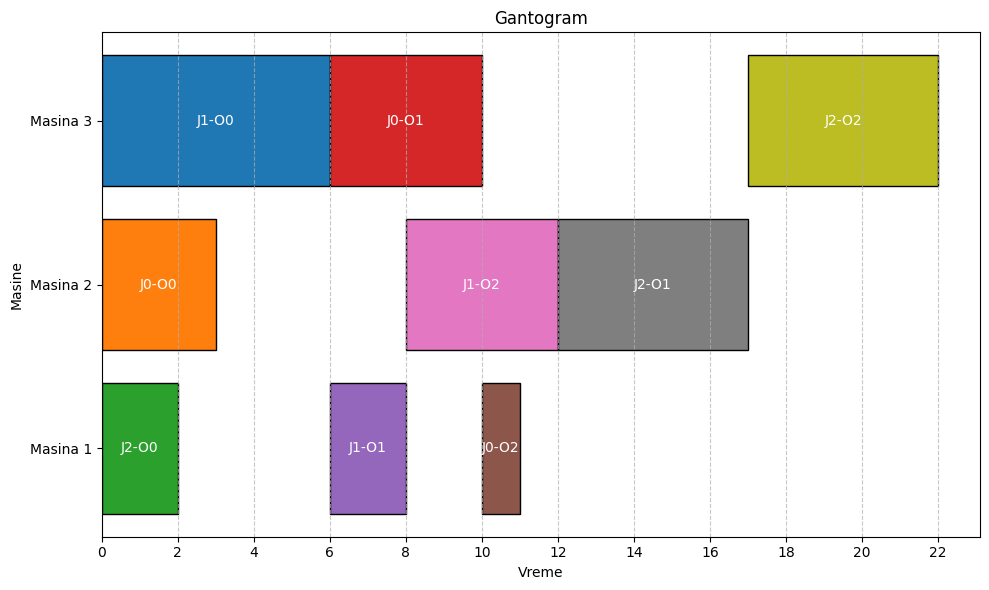

In [5]:
# gantogram jedinke iz primera
machine_sequence=np.array([[2, 3, 1],[3, 1, 2],[1, 2, 3]])
process_time=np.array([[3,4,1],[6,2,4],[2,5,5]])
chromosom=[1,0,2,0,1,0,1,2,2] # indeksiranje pocinje od 0
plot_ganttogram(chromosom, process_time, machine_sequence)


### Оцена вредности критеријума оптималности

У свакој итерацији генетског алгоритма потребно је одредити вредност критеријума оптималности за сваку од јединки како би се даље вршилло рангирање јединки и слеекција. На основу генерисаног Гантограма јасно је да је укупно време извршавања послова 22 временске јединице, што представља вредност критеријума оптималности ове јединке у скалду са поставком проблема.

In [6]:
# implmentacija funckije za izracunavanje ukupnog vremena izvrsavanja poslova

def makespan(chromosomes, population_size, num_jobs, process_time, num_machines, machine_sequence): #process_time i machine_sequnce predtavljaju matrice koje sadrze informacije masiniama na kojima se operacije izvrsavaju i vremenu izvrsavanja

    chrom_fitness, chrom_fit=[],[]
    for pop_size in range(population_size):
        j_keys=[j for j in range(num_jobs)]
        key_count={key:0 for key in j_keys}
        j_count = {key:0 for key in j_keys}
        m_keys = [j+1 for j in range(num_machines)]
        m_count = {key:0 for key in m_keys}
        for i in chromosomes[pop_size]:
            get_time=int(process_time[i][key_count[i]])
            gen_mach = int(machine_sequence[i][key_count[i]])
            j_count[i]=j_count[i]+get_time
            m_count[gen_mach]=m_count[gen_mach]+get_time
            if m_count[gen_mach] < j_count[i]:
                    m_count[gen_mach] = j_count[i]
            elif m_count[gen_mach] > j_count[i]:
                    j_count[i] = m_count[gen_mach]

            key_count[i] = key_count[i] + 1

        makespan = max(j_count.values())
        chrom_fitness.append(1/makespan)
        chrom_fit.append(makespan)


    return chrom_fit, chrom_fitness

### Селкција

Селекцију родитељских јединки могуће је имплменетирати на више начина

In [7]:
 # implemntacija rangiranja jedinki i ruletske selekcije
def cost_func(chromosomes, population_size, num_job, process_time, num_machine, machine_sequence,):
    chrom_fit, chrom_fitness=makespan(chromosomes, population_size, num_job, process_time, num_machine, machine_sequence)
    return chrom_fitness, chrom_fit

def rank(cost, chromosomes, population_size, num_job, process_time, num_machine, machine_sequence, population_list):
    costs, chrom_fit = cost_func(chromosomes, population_size, num_job, process_time, num_machine, machine_sequence)
    ranked = sorted(list(zip(chromosomes, costs, chrom_fit, population_list)), key=lambda c: c[2])
    ranked_chrom, ranked_costs, ranked_chrom_fit, ranked_population_list = list(zip(*ranked))
    ranked_chrom = list(ranked_chrom)
    ranked_chrom_fit = list(ranked_chrom_fit)
    return ranked_chrom, ranked_costs, ranked_chrom_fit

def natural_selection(ranked_parents, n):
    return ranked_parents[:n]

def roulette_selection(parents):

  pairs = []
  i = 0
  for i in range(0, len(parents), 2):
    weights=[];
    for i in range(len(parents)):
        weights.append((len(parents)-i)*random.random())
    if (weights[0]>=weights[1]):
        maxInd1=0;
        maxInd2=1;
    else:
        maxInd1=1;
        maxInd2=0;

    for i in range(2,len(parents)):
        if weights[i]>weights[maxInd1]:
            maxInd2=maxInd1
            maxInd1=i
        elif weights[i]>weights[maxInd2]:
            maxInd2=1
    pairs.append([parents[maxInd1], parents[maxInd2]])

  return pairs

### Укрштање

Код јединки кодираних на овај начин оператор укрштања је специфичан јер потомачке јединке, исто као и родитељске, морају садржати $n*m$ гена, где се сваки посао $n$ понавља $m$ пута.
* Покушај једнотачкастог укрштања

  Једнотачкасто укрштање подраумева насумично одабрану тачка у хромозомима родитеља, а делови хромозома изнад те тачке затим се размењују између родитеља.


  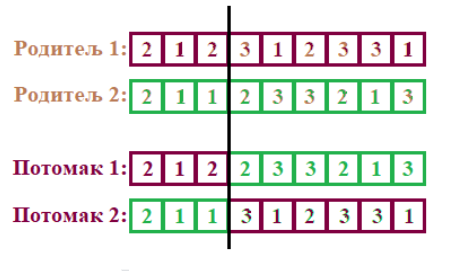
  
  * На овај начин добијени потомциниси адекватна решења проблема, на пример, потомак 1 садржи два гена која се односе на први посао, уместо три.

  Оператор укрштања је могуће имплментирати на много начина.



### Укршање поделом на дисјунктивне скупове

Уколико се проблем састоји од $n$ послова, први корак је креирања скупа $s = \{1, 2, \dots, n\}$, а затим насумична подела на два дисјунктивна подскупа $ s_1$ и $s_2$. Потомак се генерише тако што се распоред послова из подскупа $ s_1 $ директно пресликава из првог родитеља, а остатак празних поља попуњава се пословима из подскупа $s_2$ редоследом којим се појављују у другом родитељу. На аналоган начин се генерише и други потомак. Пример са слике илуструје укрштања родитеља где је скуп $ s = \{1, 2, 3\} $ подељен на подскупове $ s_1 = \{1\} $ и $ s_2 = \{2, 3\}$. Сви послови означени са 1 директно се пресликавају у потомачку једницу, а остала празна места попуњавају се генима који означавају послове 2 и 3 редом којим се појављују у другој родитељској јединци.

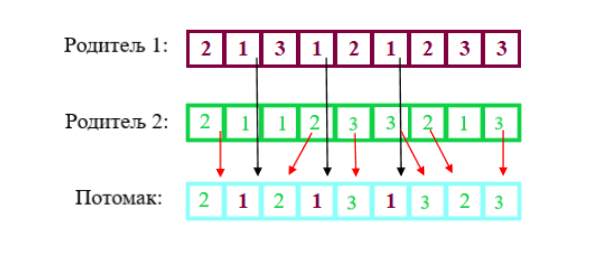

In [8]:
# implmentacija ukrstanja

def crossover(pairs, num_job):
    children=[]
    set=list(range(num_job)) # skup s
    for a,b in pairs: # roditeljske jedinke a i b
        child1=[-1]*len(a)
        child2=[-1]*len(b)
        temp_a=[]
        temp_b=[]
        m=0
        k=0
        parent1=copy.deepcopy(a)
        parent2=copy.deepcopy(b)
        r1= random.randrange(1,num_job-1)
        set1=set[:r1] # skup s1
        set2=set[r1:] # skup s2
        for i in range(len(a)):
            if a[i] in set1: # ukoliko je i-ti gen roditeljske jedinke a iz skupa s1 preslikava se na i-tu poziciju prve potomacke jedinke
                child1[i]=a[i]
                temp_a.append(a[i])
        for j in range(len(b)):
            if b[j] in set2: # ukoliko je i-ti gen roditeljske jedinke b iz skupa s1 preslikava se na i-tu poziciju druge potomacke jedinke
                child2[j]=b[j]
                temp_b.append(b[j])
        for l in range(len(child1)):
            if child1[l]==-1:
                child1[l]=temp_b[m]
                m+=1
        for f in range(len(child2)):
            if child2[f]==-1:
                child2[f]=temp_a[k]
                k+=1

        children.append(child1)
        children.append(child2)
    return children

In [9]:
# test
pairs = [[[1, 0, 2, 0, 1, 0, 1, 2, 2], [1, 0, 0, 1, 2, 2, 1, 0, 2]]]

# Poziv funkcije
crossover(pairs, 3)


[[1, 0, 1, 0, 2, 0, 2, 1, 2], [1, 0, 0, 1, 2, 2, 1, 0, 2]]

### Мутација

Оператор мутације се, као и оператор укрштања, мора прилагодити проблему тако да након мутирања јединки добијени хромозоми буду валидна решења проблема.

 * Мутација ротирањем послова

   Унутар јединке одабирају се два насумична гена који замењују позиције. На тај начин резултујућа јединака проширује простор претраге насумичним изменама, али не нарушава начин репрезентовања јединки.
     
   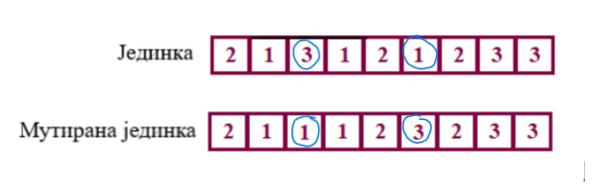

In [10]:
# implementacija mutacije rotacijom poslova
def mutation(population_list,mutation_rate):
    mutated_population=[]
    for chromosome in population_list:
        r=random.random();
        mutated_chrom=[]
        if r<mutation_rate:
            r1=random.randrange(0,len(chromosome))
            r2=random.randrange(0,len(chromosome))
            mutated_chrom=chromosome
            mutated_chrom[r1],mutated_chrom[r2]=mutated_chrom[r2],mutated_chrom[r1]
            mutated_population.append(mutated_chrom)
        else:
            mutated_population.append(chromosome)
    return mutated_population

  * Мутирање инверзијом послова

  Подразумева генерисање два насумична индекса и да се сви гени који се налазе унутар дела хромозома одређеним изгенерисаним индексима инвертују, односно да се њихов редослед замени

  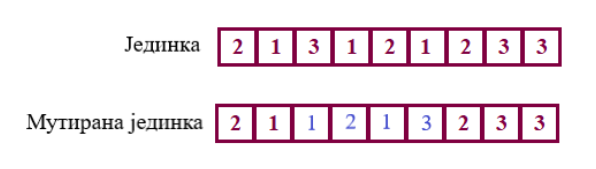

In [11]:
# implmenttacija mutacije inverzijom
def inverse_mutation(offspring_list, mutation_rate):
    mutated_pop=[]
    for chrom in offspring_list:
        r=random.random()
        if r<mutation_rate:
            r1=random.randrange(0, len(chrom))
            r2=random.randrange(0, len(chrom))
            if r1<r2:
                temp_list=chrom[r1:r2]
                temp_list.reverse()
                chrom[r1:r2]=temp_list
            elif r2<r1:
                temp_list=chrom[r2:r1]
                temp_list.reverse()
                chrom[r2:r1]=temp_list
            mutated_pop.append(chrom)
        else:
            mutated_pop.append(chrom)
    return mutated_pop


In [12]:
### Елитизам


def elitis(ranked_parenst, ranked_children, elitis_rate, population_size):
    old_ind_size=int(np.round(population_size*elitis_rate))
    return ranked_parenst[:old_ind_size]+ranked_children[:(population_size-old_ind_size)]

optimal sequence [1, 2, 0, 3, 1, 2, 4, 2, 4, 2, 1, 3, 3, 4, 3, 0, 0, 3, 1, 4, 4, 2, 0, 0, 2, 4, 1, 1, 0, 3]
optimal value:59.000000




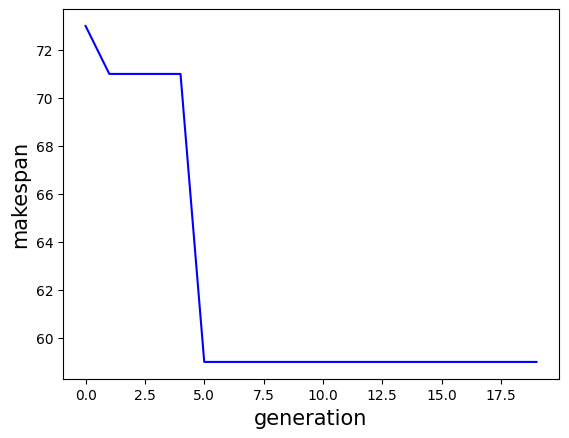

In [15]:


def job_schedule(cost_func, population_size = 5, elitis_rate=0.1, mutation_rate=0.3, inverse_mutation_rate=0.2, num_iteration = 20):
    makespan_record=[]
    machine_sequence = np.array([[3,1,2,4,6,5],[2,3,5,6,1,4], [3,4,6,1,2,5],[2,1,3,4,5,6],[3,2,5,6,1,4]])
    process_time = np.array([[1,3,6,7,3,6],[8,5,10,10,10,4],[5,4,8,9,1,7],[5,5,5,3,8,9],[3,3,9,10,4,1]])

    num_job,num_machine=process_time.shape

    avg_list=[]
    Tbest=math.inf
    same=0

    population_list=generate_initial_population(num_job, num_machine ,population_size)
    chromosomes=population_list

    for iteration in range(num_iteration):
        Tbest_now = math.inf

        parents, costs, chrom_fit=rank(cost_func,chromosomes, population_size, num_job, process_time, num_machine, machine_sequence, population_list)

        pairs=roulette_selection(parents)

        offspring_list= crossover(pairs, num_job)

        offspring_list=mutation(offspring_list,mutation_rate)

        offspring_list=inverse_mutation(offspring_list,inverse_mutation_rate)

        ranked_children,costs_children,chrom_fit_children=rank(cost_func,offspring_list,population_size,num_job,process_time,num_machine,machine_sequence,population_list)

        chromosomes=elitis(parents,ranked_children,elitis_rate,population_size)


        for pop_size in range(population_size):
            if chrom_fit[pop_size] < Tbest_now:
                Tbest_now = chrom_fit[pop_size]
                sequence_now = copy.deepcopy(chromosomes[pop_size])
        if Tbest_now < Tbest:
            Tbest = Tbest_now
            sequence_best = copy.deepcopy(sequence_now)
        if Tbest_now==Tbest:
            same+=1
        if same>15:
            break
        makespan_record.append(Tbest)

    print("optimal sequence", sequence_best)
    print("optimal value:%f"%Tbest)
    print("\n")

    plt.plot([i for i in range(len(makespan_record))],makespan_record,'b')
    plt.ylabel('makespan', fontsize=15)
    plt.xlabel('generation', fontsize=15)
    plt.show()

    return Tbest

schedule = job_schedule(cost_func)